In [3]:
import re
import html
import emoji
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from summaries import Cleaner
from summaries import Analyzer
import csv
import ast

%matplotlib inline

# Load and Clean Dataset

In [4]:
DATA_PATH  = "/home/jacob/release/"
TRAIN_FILE = "train.jsonl.gz"
TEST_FILE  = "test.jsonl.gz"
VAL_FILE   = "dev.jsonl.gz"

DROP_COLS = ['url', 'archive', 'title', 'date',
             'coverage', 'density', 'compression_bin',
             'coverage_bin', 'density_bin']


In [ ]:
def clean_and_unescape(text: str) -> str:
    """Single-pass clean: unescape HTML, strip newlines, URLs, emails,
    emojis, repeated chars, and extra whitespace."""
    try:
        text = html.unescape(text)                          # unescape HTML entities
        text = text.replace("\n", " ")                      # strip newlines
        text = re.sub(r"http\S+|www\S+", "", text)         # remove URLs
        text = re.sub(r"\S+@\S+", "", text)                # remove emails
        text = emoji.replace_emoji(text, replace="")        # remove emojis
        text = re.sub(r"(.)\1{2,}", r"\1\1", text)         # reduce repeated chars
        text = re.sub(r"\s+", " ", text).strip()           # normalize whitespace
        return text
    except Exception as e:
        print(f"Warning: clean_and_unescape failed: {e}")
        return text

In [ ]:
# Chunk each file, clean, filter compression >= 2 early to save memory, save to cleaned/
processed = {"train": [], "test": [], "dev": []}

for file, split_name in [(TRAIN_FILE, "train"), (TEST_FILE, "test"), (VAL_FILE, "dev")]:
    reader = pd.read_json(DATA_PATH + file, lines=True, compression='gzip', chunksize=200_000)
    for chunk_idx, df in enumerate(reader):
        df = df.drop(columns=DROP_COLS)

        # Single-pass clean (replaces separate html.unescape + clean_text calls)
        df["text"]    = df["text"].apply(clean_and_unescape)
        df["summary"] = df["summary"].apply(clean_and_unescape)

        # Filter low-compression rows early to reduce memory before concat
        df = df[df["compression"] >= 2].reset_index(drop=True)

        out_path = f"{DATA_PATH}cleaned/{split_name}_{chunk_idx}.csv"
        df.to_csv(out_path, index=False)
        processed[split_name].append(out_path)
        print(f"Saved {out_path} ({len(df):,} rows)")

In [4]:

processed = {"train": [f"/home/jacob/release/cleaned/train_{i}.csv" for i in range(5)],
             "test": ["/home/jacob/release/cleaned/test_0.csv"], "dev": ["/home/jacob/release/cleaned/dev_0.csv"]}
train_df = pd.concat((pd.read_csv(f) for f in processed["train"]), ignore_index=True)
test_df  = pd.concat((pd.read_csv(f) for f in processed["test"]),  ignore_index=True)
dev_df   = pd.concat((pd.read_csv(f) for f in processed["dev"]),   ignore_index=True)

print("Train:", len(train_df), "Test:", len(test_df), "Dev:", len(dev_df))

Train: 986855 Test: 107961 Dev: 107946


# Visualize Compression Ratio, Summary Length, Text Length

In [5]:
df = train_df  # use train for EDA

print("Text length stats:")
print(df["text"].str.len().describe())
print("\nSummary length stats:")
print(df["summary"].str.len().describe())
print("\nCompression ratio stats:")
print(df["compression"].describe())

Text length stats:
count    986855.000000
mean       3966.465424
std        4996.757306
min          34.000000
25%        1678.000000
50%        3160.000000
75%        5065.000000
max      625133.000000
Name: text, dtype: float64

Summary length stats:
count    986831.000000
mean        159.212238
std         151.794775
min           1.000000
25%          96.000000
50%         134.000000
75%         179.000000
max        9469.000000
Name: summary, dtype: float64

Compression ratio stats:
count    986855.000000
mean         44.250530
std         389.357526
min           2.000000
25%          12.395477
50%          24.421053
75%          44.000000
max      105559.000000
Name: compression, dtype: float64


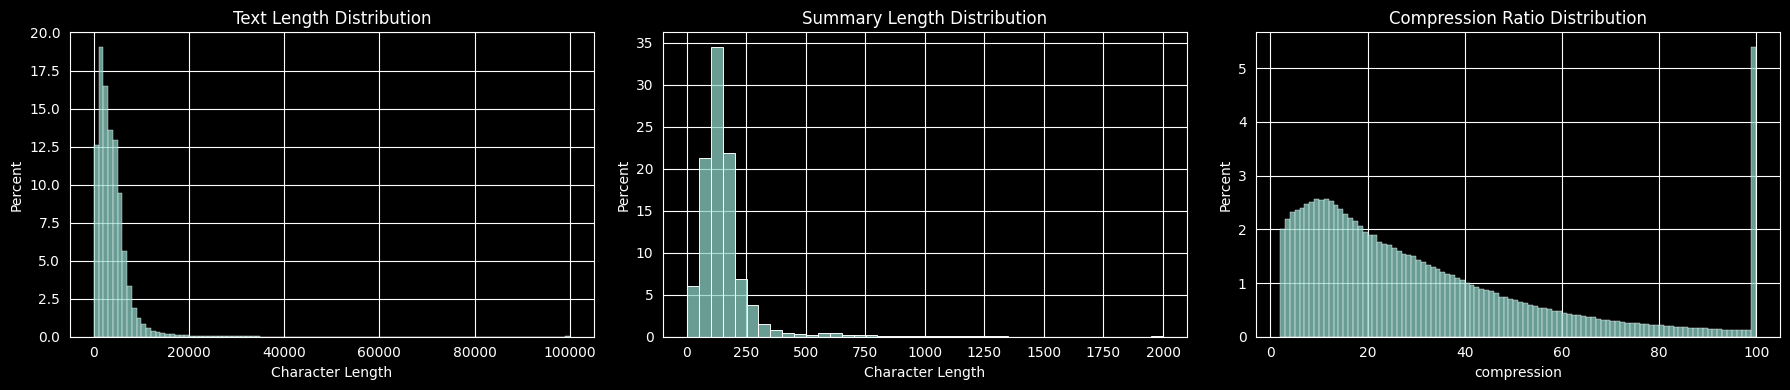

Percent with compression >= 2: 100.00%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["text"].str.len().clip(upper=100_000), kde=False, stat="percent", binwidth=1000, ax=axes[0])
axes[0].set_title("Text Length Distribution")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Percent")

sns.histplot(df["summary"].str.len().clip(upper=2000), kde=False, stat="percent", binwidth=50, ax=axes[1])
axes[1].set_title("Summary Length Distribution")
axes[1].set_xlabel("Character Length")
axes[1].set_ylabel("Percent")

sns.histplot(df["compression"].clip(upper=100), kde=False, stat="percent", binwidth=1, ax=axes[2])
axes[2].set_title("Compression Ratio Distribution")
axes[2].set_xlabel("compression")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()

pct_compression_ge2 = (df["compression"] >= 2).mean()
print(f"Percent with compression >= 2: {pct_compression_ge2:.2%}")

# Deduplicate and Filter with `summaries` Cleaner

In [5]:
# Drop NaN rows and coerce to str — NaN (float) arises from empty strings
# after CSV round-trip and causes TypeError inside Cleaner._get_length().
def prepare_for_cleaner(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(subset=["text", "summary"]).copy()
    df["text"]    = df["text"].astype(str)
    df["summary"] = df["summary"].astype(str)
    return df

In [7]:
print(f"Before null drop — train: {len(train_df):,}  val: {len(dev_df):,}  test: {len(test_df):,}")
train_df = prepare_for_cleaner(train_df)
dev_df   = prepare_for_cleaner(dev_df)
test_df  = prepare_for_cleaner(test_df)
print(f"After null drop — train: {len(train_df):,}  val: {len(dev_df):,}  test: {len(test_df):,}")

analyzer = Analyzer(lemmatize=True, lang="en", print_cutoff_length=10)
cleaner  = Cleaner(analyzer, min_compression_ratio=2.0, deduplication_method="test_first")

cleaned = cleaner.clean_dataset(
    summary_text_column_name="summary",
    reference_text_column_name="text",
    train_set=train_df.to_dict(orient="records"),
    validation_set=dev_df.to_dict(orient="records"),
    test_set=test_df.to_dict(orient="records"),
    enable_tqdm=True,
    print_breakdown=True,
)



train_df = pd.DataFrame(cleaned["train"])
dev_df   = pd.DataFrame(cleaned["validation"])
test_df  = pd.DataFrame(cleaned["test"])
del cleaned
print(f"After cleaning — train: {len(train_df):,}  val: {len(dev_df):,}  test: {len(test_df):,}")

Before null drop — train: 986,855  val: 107,946  test: 107,961
After null drop — train: 986,831  val: 107,943  test: 107,960


100%|██████████| 986831/986831 [00:02<00:00, 423743.49it/s]


29744 samples were removed from the dataset.
Breakdown by filter category:
'reference_too_short': {'train': 0, 'validation': 0, 'test': 0} samples removed across splits.
'summary_too_short': {'train': 0, 'validation': 0, 'test': 0} samples removed across splits.
'identity_sample': {'train': 0, 'validation': 0, 'test': 0} samples removed across splits.
'compression_ratio': {'train': 1926, 'validation': 224, 'test': 227} samples removed across splits.
'extractiveness': {'train': 0, 'validation': 0, 'test': 0} samples removed across splits.
'exact_duplicate': {'train': 2154, 'validation': 129, 'test': 66} samples removed across splits.
'both_duplicate': {'train': 109, 'validation': 5, 'test': 4} samples removed across splits.
'summary_duplicate': {'train': 13465, 'validation': 1175, 'test': 980} samples removed across splits.
'reference_duplicate': {'train': 7699, 'validation': 819, 'test': 762} samples removed across splits.
After cleaning — train: 961,478  val: 105,591  test: 105,921


# Train BPE Tokenizer

In [ ]:
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
    vocab_size=50_000,
    min_frequency=2,
    show_progress=True,
)

all_texts = list(train_df["text"]) + list(train_df["summary"])
tokenizer.train_from_iterator(all_texts, trainer=trainer)

tokenizer.save(DATA_PATH + "bpe_tokenizer.json")
print("BPE tokenizer trained and saved. Vocab size:", tokenizer.get_vocab_size())

# Filter by Token Length: Summary [1–1000], Text [2–2000] and save to disk

In [6]:
def tokenize_filter_save(df, tokenizer, out_path,
                         min_text=10, max_text=2000,
                         min_summary=1, max_summary=1000,
                         batch_size=10_000):
    texts     = [str(x) for x in df["text"]]
    summaries = [str(x) for x in df["summary"]]
    n = len(df)
    kept = 0

    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["text", "summary"])
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            text_encs    = tokenizer.encode_batch(texts[start:end])
            summary_encs = tokenizer.encode_batch(summaries[start:end])
            for te, se in zip(text_encs, summary_encs):
                if min_text <= len(te.ids) <= max_text and min_summary <= len(se.ids) <= max_summary:
                    writer.writerow([te.ids, se.ids])
                    kept += 1
            del text_encs, summary_encs

    return kept

splits = {"train": train_df, "test": test_df, "dev": dev_df}
tokenizer = Tokenizer.from_file(DATA_PATH + "bpe_tokenizer.json")

for name, df in splits.items():
    before = len(df)
    df = prepare_for_cleaner(df)
    out_path = DATA_PATH + f"final/{name}.csv"
    kept = tokenize_filter_save(df, tokenizer, out_path)
    print(f"{name}: {before:,} -> {kept:,} rows saved to {out_path}")
    del df

train: 986,855 -> 942,535 rows saved to /home/jacob/release/final/train.csv
test: 107,961 -> 103,220 rows saved to /home/jacob/release/final/test.csv
dev: 107,946 -> 103,181 rows saved to /home/jacob/release/final/dev.csv


# Final Distribution After All Filtering

In [5]:
df = pd.read_csv(DATA_PATH + "final/train.csv")

text_lengths    = df["text"].str.count(",") + 1
summary_lengths = df["summary"].str.count(",") + 1
compression     = text_lengths / summary_lengths



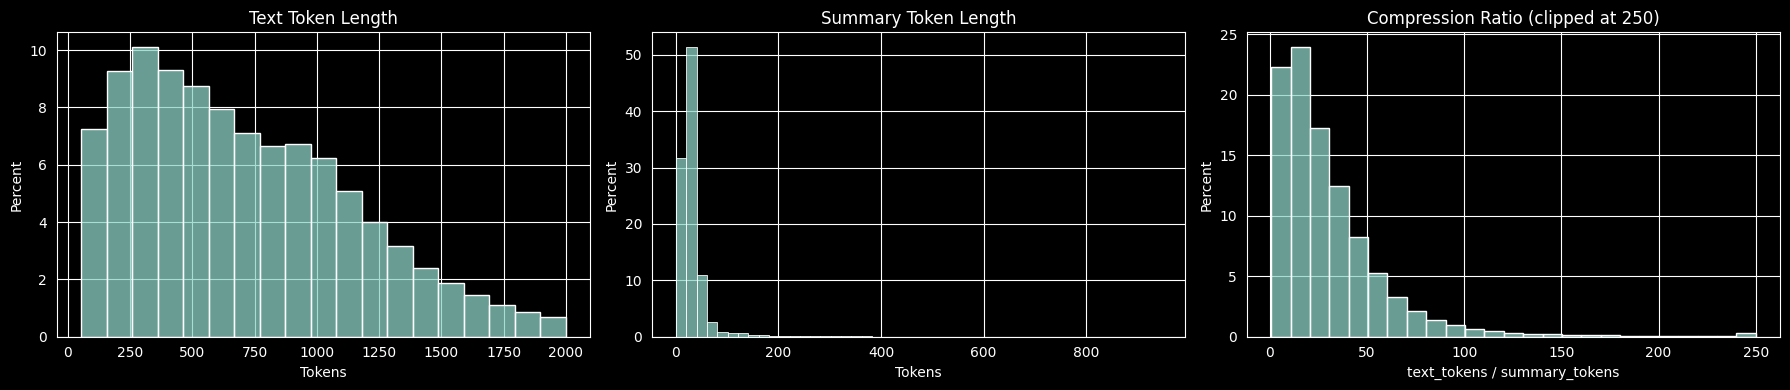

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(text_lengths, kde=False, stat="percent", binwidth=100, ax=axes[0])
axes[0].set_title("Text Token Length")
axes[0].set_xlabel("Tokens")

sns.histplot(summary_lengths, kde=False, stat="percent", binwidth=20, ax=axes[1])
axes[1].set_title("Summary Token Length")
axes[1].set_xlabel("Tokens")

sns.histplot(compression.clip(upper=250), kde=False, stat="percent", binwidth=10, ax=axes[2])
axes[2].set_title("Compression Ratio (clipped at 250)")
axes[2].set_xlabel("text_tokens / summary_tokens")

plt.tight_layout()
plt.show()